In [23]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE


In [26]:
df=pd.read_csv('2_preprocessed_encoded.csv')

In [27]:
# 1. Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

# 2. Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [30]:
# 3. Standardize the resampled data
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# 4. Apply PCA on the scaled, resampled data
pca = PCA(n_components=0.95)  # keep 95% variance
X_pca = pca.fit_transform(X_resampled_scaled)

In [31]:
# 5. Create a DataFrame of PCA features and add target
df_pca = pd.DataFrame(X_pca)
df_pca['target'] = y_resampled.values

# 6. Check explained variance
explained_variance = pca.explained_variance_ratio_
print(f'Explained variance: {explained_variance}')
print(f'Total explained variance: {explained_variance.sum()}')

Explained variance: [0.16168637 0.09757114 0.07951047 0.05539703 0.05431776 0.05124327
 0.04978462 0.04923003 0.04785658 0.04768652 0.04717057 0.04430487
 0.04158558 0.03985624 0.03900883 0.03452996 0.02859427]
Total explained variance: 0.9693341332828861


In [33]:
df_pca

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,target
0,-0.434019,-2.075411,1.682866,-0.901955,-1.035468,-1.534607,-0.551397,3.886278,0.480600,-0.254726,-0.986516,-0.063365,1.479826,-0.964578,-2.394426,-0.162737,-0.709376,0
1,-2.115327,-0.139355,1.991799,-1.446826,0.517958,-0.512915,-1.747450,-0.365819,-0.981674,-0.054486,1.115256,-0.084612,0.621884,0.406868,1.803203,-2.090109,-0.875734,0
2,1.887703,0.217024,-0.565374,-0.119337,0.360809,-0.118378,0.189500,-0.006913,-0.040876,0.002867,0.106579,-0.298041,-0.419733,-0.510730,-0.195114,0.387753,-1.058848,0
3,1.183511,2.541196,-0.150743,1.301559,-1.027528,0.465985,-0.353777,0.377968,-0.031705,-0.120372,-0.047073,2.644880,-1.152224,0.317607,0.326364,-0.330119,-0.373070,0
4,-0.374674,-1.208440,-0.976709,1.678932,-1.236418,0.758536,-0.174671,0.373533,-0.545136,-0.148411,0.744809,2.104769,-1.084097,1.013386,1.023524,-0.985341,1.833668,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74213,-1.238905,0.157813,-1.146843,0.009576,-0.520976,0.490536,0.079495,0.073513,-0.422219,0.025519,0.576171,-0.417072,-0.682889,0.216349,0.272853,0.083750,0.052025,1
74214,-2.247470,-0.996156,1.232362,0.476181,1.650867,-0.604421,3.144808,0.219837,1.022755,-0.059788,-1.135207,-0.009852,-0.170387,0.436721,1.211184,-0.247800,-0.980786,1
74215,-2.608702,-1.127144,1.293577,1.927516,-1.133835,0.536873,-0.980977,-1.704145,0.337914,0.392872,-0.564955,-1.587860,-0.596428,0.048648,-0.440220,-0.290429,0.017212,1
74216,-2.454450,-0.323498,-1.252296,0.004359,-0.336947,0.202769,-0.102251,-0.036325,-0.185946,-0.034845,0.269004,-0.027668,-0.280893,0.657743,0.565087,0.819224,-0.400530,1


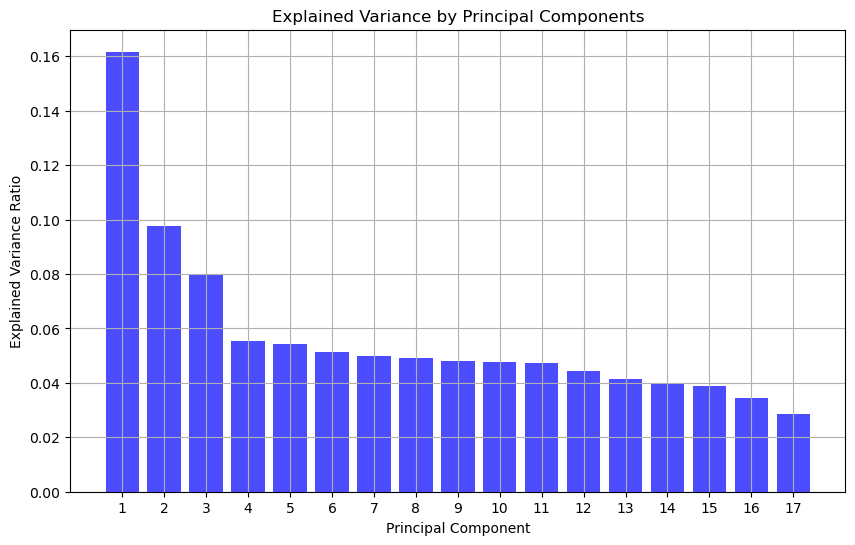

In [34]:

df_pca.to_csv('2_pca_transformed.csv', index=False)
# Plot the explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='blue')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()
plt.show()


In [35]:
df_pca.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,target
0,-0.434019,-2.075411,1.682866,-0.901955,-1.035468,-1.534607,-0.551397,3.886278,0.480600,-0.254726,-0.986516,-0.063365,1.479826,-0.964578,-2.394426,-0.162737,-0.709376,0
1,-2.115327,-0.139355,1.991799,-1.446826,0.517958,-0.512915,-1.747450,-0.365819,-0.981674,-0.054486,1.115256,-0.084612,0.621884,0.406868,1.803203,-2.090109,-0.875734,0
2,1.887703,0.217024,-0.565374,-0.119337,0.360809,-0.118378,0.189500,-0.006913,-0.040876,0.002867,0.106579,-0.298041,-0.419733,-0.510730,-0.195114,0.387753,-1.058848,0
3,1.183511,2.541196,-0.150743,1.301559,-1.027528,0.465985,-0.353777,0.377968,-0.031705,-0.120372,-0.047073,2.644880,-1.152224,0.317607,0.326364,-0.330119,-0.373070,0
4,-0.374674,-1.208440,-0.976709,1.678932,-1.236418,0.758536,-0.174671,0.373533,-0.545136,-0.148411,0.744809,2.104769,-1.084097,1.013386,1.023524,-0.985341,1.833668,0


In [36]:
from sklearn.model_selection import train_test_split

In [37]:
X= df_pca.drop("target", axis=1)
y= df_pca["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [38]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, validation_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE

In [39]:
# 6. Initialize Random Forest
rf = RandomForestClassifier(random_state=42)